# Zomato Data Analysis Project

### Step 1 - Importing Libraries

In [4]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 5.0 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 5.0 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 5.0 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 2.8 MB/s eta 0:00:02
   ------------------ --------------------- 3.9/8.3 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 3.2 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 2.6 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 2.5 MB/s eta 0:00:02
   -------------------------------- ------- 6.8/8.3 MB 2.9 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.1 MB/s eta 0:00:01
   ----------------

In [13]:
!pip install seaborn

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 - Create the data frame

In [15]:
df = pd.read_csv("zomato_data.csv")

In [16]:
df.head(5)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### Convert the data type of column - rate

In [17]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

df['rate'] = df['rate'].apply(handleRate)
print(df.head(5))

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB


 ### Q1. What type of restaurant do the majority of customers order from?

Text(0, 0.5, 'Count of Resturant')

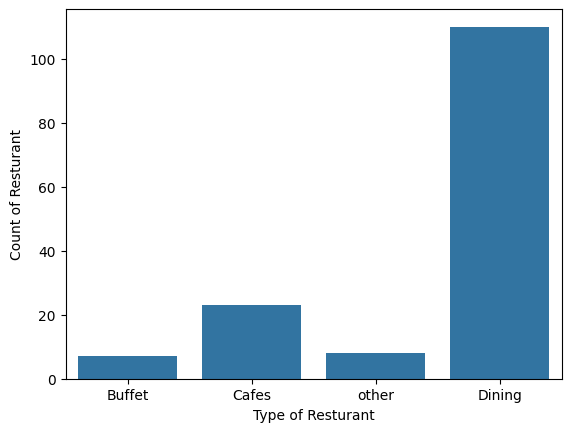

In [23]:
sns.countplot(x = df['listed_in(type)'])
plt.xlabel("Type of Resturant")
plt.ylabel("Count of Resturant")

---

- Conclusion : Majority of the resturant falls in Dining type.

---

### Q2. How many votes has each type of restaurnat received from customers?

In [26]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})


In [27]:
result

,votes
listed_in(type),
Buffet,3028
Cafes,6434
Dining,20363
other,9367


Text(0, 0.5, 'Votes')

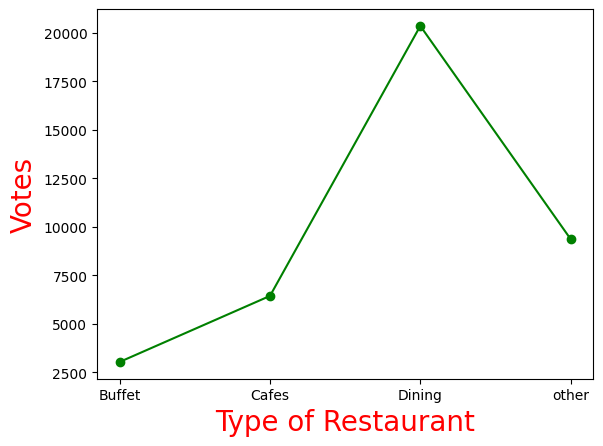

In [54]:
plt.plot(result, c = 'green', marker = 'o')
plt.xlabel("Type of Restaurant", c = 'red', size = 20)
plt.ylabel("Votes", c = "red", size = 20)

---

- Conclusion : Dining resturants has recieved maximum votes

---

### Q3. What are the ratings that the majority of restaurants have received ?

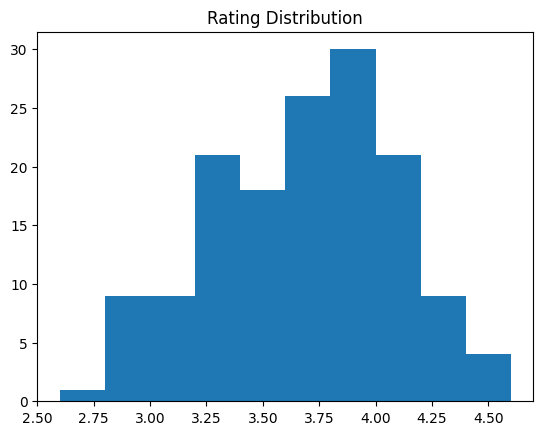

In [40]:
plt.hist(df['rate'], bins = 10)
plt.title("Rating Distribution")
plt.show()

- Conclusion : The majority resturants received ratings from 3.5 to 4

---

### Q4. Average Order Spendnig By Couples

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

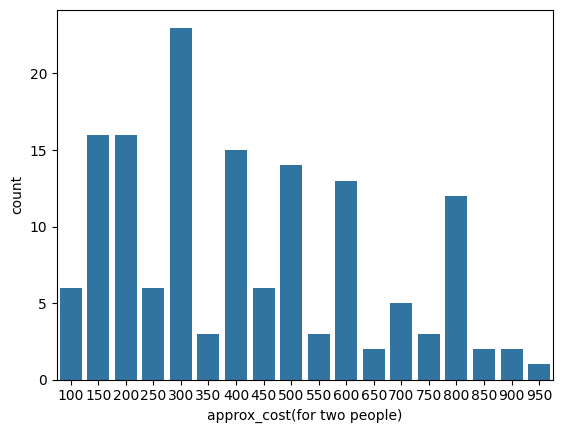

In [41]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x=couple_data)

- Conclusion : The majority of couples prefer resturants with an approximate cost of 300 rupees.

### Q5. Which mode received maximum rating?

In [43]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='online_order', ylabel='rate'>

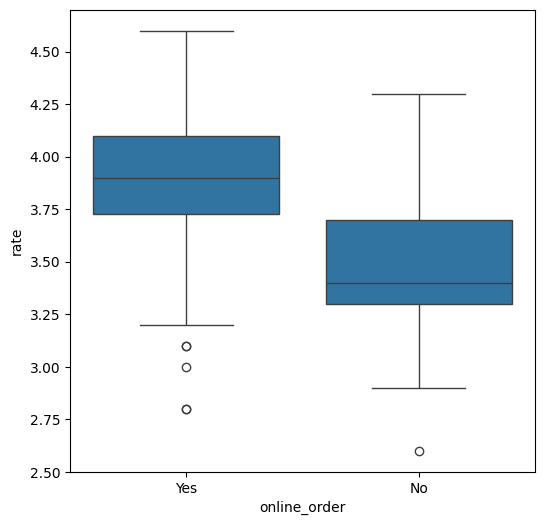

In [47]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order' , y = 'rate', data = df)

- Conclusion : Offline order received lower rating in comparsion to online orders

### Q6. Which type of restaurant received more offline orders, so that Zomato can provide customers with some good offers. 

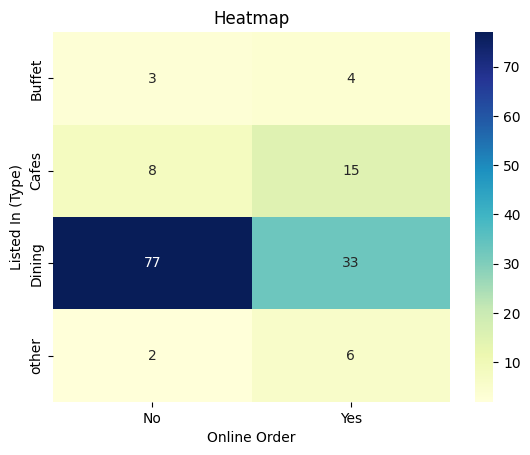

In [52]:
pivot_table = df.pivot_table(index='listed_in(type)', columns = 'online_order', aggfunc = 'size', fill_value = 0)
sns.heatmap(pivot_table, annot = True, cmap = "YlGnBu", fmt = 'd')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In (Type)")
plt.show()

- Conclusion : Dining restaurantts prmiarily accept offline ordre, whereas cages primarily receive online order.  This suggest that clients prefers orders in person at restaurants, but prefer online ordering at cafes.